# Inverse figures for transition from Loop 0 to Loop 1. 

Notebook to generate the frames of the inverse model's results for Figure 3. The task is optimization of MgkPro:
1. PCA of generated candidates from Loop 0 and Loop 1.
2. End-to-End optimization comparison verween Loop 0 and Loop 1.
3. Counterfactual experiment on solutions from Loop 0.

## Prepare Notebook.

### Import Libraries.

In [1]:
import os
import sys
import yaml

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc
from scipy.stats import gaussian_kde
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
from tqdm import tqdm


### Define Constants.

In [2]:
# ---- Loop 0 paths ----
# 1. Anndata
h5ad_path_loop0_concat = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_old_experiments_.h5ad"
h5ad_path_loop0_subset = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_old_experiments_.h5ad"

# 2. Candidates
loop0_candidates_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm_old_measurements_official"

# ---- Loop 0 paths ----
# 1. Anndata
h5ad_path_loop1_concat = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_.h5ad"
h5ad_path_loop1_subset = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad"

# 2. Candidates
loop1_candidates_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm_official"

# ---- Other paths and configurations ----
annotation_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/forward/conditional_model/flow_matching/config/annotation/bloodplus.yaml"
constraints_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
target_cell_type = "late_MgkPro"

## Load Configurations.

### Load Annotation Configurations.

In [3]:
# ---- 1. Open Files ----
with open(annotation_config_path, "r") as fb:
    annotation_config = yaml.safe_load(fb)

# ---- 2. Retrieve Fields of Interest ----
protocol_cols = annotation_config["protocol_columns"]
scatter_cols = annotation_config["scatter_columns"]
print(f"{protocol_cols=}")
print(f"{scatter_cols=}")


protocol_cols=['gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture']
scatter_cols=['FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width']


### Load Constraints condigurations.

In [4]:
# ---- 1. Open Files ----
with open(constraints_config_path, "r") as fb:
    constraints_config = yaml.safe_load(fb)

# ---- 2. Retrieve Fields of Interest ----
lbound_dict = constraints_config["lbound_dict"]
ubound_dict = constraints_config["ubound_dict"]
print(f"{lbound_dict=}")
print(f"{ubound_dict=}")


lbound_dict={'gm-csf_[ng_ml]': 0.0, 'tpo_[ng_ml]': 0.0, 'um171_[nm]': 0.0, 'um729_[µm]': 0.0, 'sr1_[nm]': 0.0, 'scf_[ng_ml]': 0.0, 'butyzamide_[nm]': 0.0, 'retinoic_acid_[µm]': 0.0, 'ldl_[ng_ml]': 0.0, 'il3_[ng_ml]': 0.0, 'o2_[%]': 10.0, 'days_of_culture': 12.0}
ubound_dict={'gm-csf_[ng_ml]': 10.0, 'tpo_[ng_ml]': 2.5, 'um171_[nm]': 1120.0, 'um729_[µm]': 1120.0, 'sr1_[nm]': 750.0, 'scf_[ng_ml]': 50.0, 'butyzamide_[nm]': 100.0, 'retinoic_acid_[µm]': 25.0, 'ldl_[ng_ml]': 50.0, 'il3_[ng_ml]': 20.0, 'o2_[%]': 20.0, 'days_of_culture': 18.0}


# Load Candidates Data.

## Utility Functions to Load and Filter Candidates Data. 

### Function to Load the Candidates Data.

In [5]:
def load_candidates(candidates_base_dir, target_ct):
    # ---- 1. Get optimization modes ----
    opt_modes_list = os.listdir(candidates_base_dir)

    # ---- 2. Iterate over optimization modes ----
    all_records = []
    for opt_mode in opt_modes_list:
        # ---- 3. (OPT MODE) Get directory and check it exists ----
        opt_mode_base_dir = os.path.join(candidates_base_dir, opt_mode, target_ct)
        if not os.path.isdir(opt_mode_base_dir):
            continue

        # ---- 4. (OPT MODE) List all runs ----
        runs_list = os.listdir(opt_mode_base_dir)

        # ---- 5. (RUNS) Iterate over all runs ----
        for run_id in runs_list:
            # ---- 6. (RUNS) Get file paths for current run ----
            run_dir = os.path.join(opt_mode_base_dir, run_id, "uncertainty_annotation")
            csv_path = os.path.join(run_dir, "candidates_with_uncertainties.csv")
            
            # ---- 7. (RUNS) Check that file exist ----
            if not os.path.exists(csv_path):
                print(f"Missing files for {opt_mode}/{run_id}, skipping")
                continue
            
            # ---- 8. (RUNS) Read and update csv ----
            # Read data from disk
            df = pd.read_csv(csv_path)

            # Add column names
            df["run"] = run_id
            df["opt_mode"] = opt_mode

            # Update recors
            all_records.append(df)

    # concatenate candidates
    return pd.concat(all_records, ignore_index=True)


### Function to Filter Candidates Data.

In [6]:
def filter_candidates(candidates_df, lbound_dict, ubound_dict, protocol_cols, margin = 0.1):
    # ---- 1.  Target Markers Loop ----
    print("---- Filtering Results ----")
    # define mask for all columns
    marker_mask = np.full(candidates_df.shape[0], True)

    # ----  Protocol Columns Loop ----
    for col in protocol_cols:
        # get col bounds
        col_ubound = ubound_dict[col]
        col_lbound = lbound_dict[col]
        print(f"\t\t---- Processing Column {col} -> U: {col_ubound}, L: {col_lbound} ----")

        # get col values and mask
        col_values = candidates_df[col]
        col_mask_ubound_mask = col_values <= col_ubound*(1 + margin)
        col_mask_lbound_mask = col_values >= col_lbound*(1 - margin)

        # get masks for current column
        old_mask = marker_mask
        lbound_marker_mask = marker_mask & col_mask_lbound_mask
        ubound_marker_mask = marker_mask & col_mask_ubound_mask
        marker_mask = marker_mask & col_mask_ubound_mask & col_mask_lbound_mask

        # get number of solutions
        n_previously_accepted_solutions = old_mask.sum()
        n_accepted_solutions = marker_mask.sum()
        n_solutions_passing_ubound = col_mask_ubound_mask.sum()
        n_solutions_passing_lbound = col_mask_lbound_mask.sum()
        n_solutions_passing_ubound_and_previous_constraints = ubound_marker_mask.sum()
        n_solutions_passing_lbound_and_previous_constraints = lbound_marker_mask.sum()
        print(f"\t\t\t --- Number Previously Accepted Solutions {n_previously_accepted_solutions} ---")
        print(f"\t\t\t --- Number Currently Accepted Solutions {n_accepted_solutions} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Upper Bound {n_solutions_passing_ubound} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Lower Bound {n_solutions_passing_lbound} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Upper Bound and Previous Constraints {n_solutions_passing_ubound_and_previous_constraints} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Lower Bound and Previous Constraints {n_solutions_passing_lbound_and_previous_constraints} ---")


        # write values for constraint on current column
        candidates_df[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
        candidates_df[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask

    # write values for all constraints
    n_all_solutions = candidates_df.shape[0]
    n_accepted_solutions = marker_mask.sum()
    candidates_df["passes_constraints:all"] = marker_mask

    print(f"\t\t\t--- Finished, Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")
    return candidates_df


## Loop 0 Candidates Data.

### Load Candidates Data.

In [7]:
candidates_loop0 = load_candidates(loop0_candidates_dir, target_cell_type)
candidates_loop0

,Unnamed: 0,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],...,cfg:constraints:ubound_dict:gm-csf_[ng_ml],cfg:constraints:ubound_dict:tpo_[ng_ml],cfg:constraints:ubound_dict:um171_[nm],cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml]
0,0,late_MgkPro:2026-04-29_18-14-46_5621f33b:0,3.217864,1.232483,0.224321,0.018293,1.352498,0.003009,0.000000,0.015023,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,late_MgkPro:2026-04-29_18-14-46_5621f33b:1,5.733731,0.009683,384.913100,251.420170,0.000000,0.000000,114.951430,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,late_MgkPro:2026-04-29_18-14-46_5621f33b:2,10.162149,2.517613,295.627960,419.409900,0.041926,47.539024,0.071713,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,late_MgkPro:2026-04-29_18-14-46_5621f33b:3,9.609956,2.409408,563.735600,0.072564,0.865486,46.549767,0.076597,0.160119,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,late_MgkPro:2026-04-29_18-14-46_5621f33b:4,9.718867,2.601944,880.871460,1194.650600,0.037637,54.538450,0.000000,0.221980,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37195,45,late_MgkPro:2026-04-30_01-06-45_f4f22cca:45,8.868985,0.877943,191.139310,0.147150,0.662970,57.968956,0.315657,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37196,46,late_MgkPro:2026-04-30_01-06-45_f4f22cca:46,21.061314,4.431772,702.962460,77.849640,0.000000,17.754110,0.000000,3.586815,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37197,47,late_MgkPro:2026-04-30_01-06-45_f4f22cca:47,10.362461,2.918244,340.193540,455.833530,0.124464,48.637047,0.558616,0.605150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37198,48,late_MgkPro:2026-04-30_01-06-45_f4f22cca:48,8.507112,3.579082,101.002190,371.961580,0.000000,42.998966,0.000000,1.272915,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Filter Candidates Data.

In [8]:
margin = 0.1
candidates_loop0 = filter_candidates(candidates_loop0, lbound_dict, ubound_dict, protocol_cols, margin=margin)
candidates_loop0

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 37200 ---
			 --- Number Currently Accepted Solutions 34785 ---
			 --- Number of Solution Satisfying Upper Bound 34785 ---
			 --- Number of Solution Satisfying Lower Bound 37200 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 34785 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 37200 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 34785 ---
			 --- Number Currently Accepted Solutions 30333 ---
			 --- Number of Solution Satisfying Upper Bound 31757 ---
			 --- Number of Solution Satisfying Lower Bound 37200 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 30333 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 34785 ---
		---- Processing Column sr1_[nm] -> U: 750.0, L: 

,Unnamed: 0,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],...,passes_constraints:retinoic_acid_[µm]:lbound,passes_constraints:ldl_[ng_ml]:ubound,passes_constraints:ldl_[ng_ml]:lbound,passes_constraints:il3_[ng_ml]:ubound,passes_constraints:il3_[ng_ml]:lbound,passes_constraints:o2_[%]:ubound,passes_constraints:o2_[%]:lbound,passes_constraints:days_of_culture:ubound,passes_constraints:days_of_culture:lbound,passes_constraints:all
0,0,late_MgkPro:2026-04-29_18-14-46_5621f33b:0,3.217864,1.232483,0.224321,0.018293,1.352498,0.003009,0.000000,0.015023,...,True,True,True,True,True,True,True,True,True,True
1,1,late_MgkPro:2026-04-29_18-14-46_5621f33b:1,5.733731,0.009683,384.913100,251.420170,0.000000,0.000000,114.951430,0.000000,...,True,True,True,True,True,True,True,True,True,False
2,2,late_MgkPro:2026-04-29_18-14-46_5621f33b:2,10.162149,2.517613,295.627960,419.409900,0.041926,47.539024,0.071713,0.000000,...,True,True,True,True,True,True,True,True,True,True
3,3,late_MgkPro:2026-04-29_18-14-46_5621f33b:3,9.609956,2.409408,563.735600,0.072564,0.865486,46.549767,0.076597,0.160119,...,True,True,True,True,True,True,True,True,True,True
4,4,late_MgkPro:2026-04-29_18-14-46_5621f33b:4,9.718867,2.601944,880.871460,1194.650600,0.037637,54.538450,0.000000,0.221980,...,True,True,True,True,True,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37195,45,late_MgkPro:2026-04-30_01-06-45_f4f22cca:45,8.868985,0.877943,191.139310,0.147150,0.662970,57.968956,0.315657,0.000000,...,True,True,True,True,True,True,True,True,True,False
37196,46,late_MgkPro:2026-04-30_01-06-45_f4f22cca:46,21.061314,4.431772,702.962460,77.849640,0.000000,17.754110,0.000000,3.586815,...,True,True,True,True,True,True,True,True,True,False
37197,47,late_MgkPro:2026-04-30_01-06-45_f4f22cca:47,10.362461,2.918244,340.193540,455.833530,0.124464,48.637047,0.558616,0.605150,...,True,True,True,True,True,True,True,True,True,False
37198,48,late_MgkPro:2026-04-30_01-06-45_f4f22cca:48,8.507112,3.579082,101.002190,371.961580,0.000000,42.998966,0.000000,1.272915,...,True,True,True,True,True,True,True,True,True,False


### Get only Conditions satisfying constraints.

In [10]:
# ---- Compute masks for enrichment----
use_threshold = False
target_ct_prop = f"{target_cell_type}_prop"

if use_threshold:
    target_enrichment_goal = 0.05
    enrichment_mask = candidates_loop0[target_ct_prop] > target_enrichment_goal
else:
    percentile = 95
    val = np.percentile(candidates_loop0[target_ct_prop].values, percentile)
    print(f"Loop 0 threshold val {val.item()}")
    enrichment_mask = candidates_loop0[target_ct_prop] > val

# ---- Compute mask for bounds ----
bounds_col = "passes_constraints:all"
bounds_mask =  candidates_loop0[bounds_col]

# ---- Compute joint mask and display results ----
loop0_mask = enrichment_mask & bounds_mask

tot_candidates = len(loop0_mask)

n_bounds = bounds_mask.sum()
n_enriching = enrichment_mask.sum()
n_passing = loop0_mask.sum()
print(f"Passing filtering steps -> Enrichment: {n_enriching}/{tot_candidates}, Bounds: {n_bounds}/{tot_candidates}, Passing: {n_passing}/{tot_candidates}")

filtered_candidates_loop0 = candidates_loop0[loop0_mask]
filtered_candidates_loop0

Loop 0 threshold val 0.03817445654999986
Passing filtering steps -> Enrichment: 1860/37200, Bounds: 21952/37200, Passing: 1088/37200


,Unnamed: 0,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],...,passes_constraints:retinoic_acid_[µm]:lbound,passes_constraints:ldl_[ng_ml]:ubound,passes_constraints:ldl_[ng_ml]:lbound,passes_constraints:il3_[ng_ml]:ubound,passes_constraints:il3_[ng_ml]:lbound,passes_constraints:o2_[%]:ubound,passes_constraints:o2_[%]:lbound,passes_constraints:days_of_culture:ubound,passes_constraints:days_of_culture:lbound,passes_constraints:all
6,6,late_MgkPro:2026-04-29_18-14-46_5621f33b:6,2.534045,0.163012,16.347935,172.060580,0.000000,0.016854,103.309130,0.000000,...,True,True,True,True,True,True,True,True,True,True
31,31,late_MgkPro:2026-04-29_18-14-46_5621f33b:31,2.023707,0.138796,6.946443,150.135470,0.031481,0.060542,89.934845,0.000000,...,True,True,True,True,True,True,True,True,True,True
39,39,late_MgkPro:2026-04-29_18-14-46_5621f33b:39,0.717572,0.032075,0.808135,104.296050,0.089087,0.000000,106.310900,0.032026,...,True,True,True,True,True,True,True,True,True,True
156,6,late_MgkPro:2026-04-29_18-25-10_3c0b9d46:6,3.353832,0.093687,60.661705,196.375230,0.000000,0.001277,104.324730,0.000000,...,True,True,True,True,True,True,True,True,True,True
189,39,late_MgkPro:2026-04-29_18-25-10_3c0b9d46:39,0.671531,0.039662,1.155250,99.890625,0.095823,0.000000,106.203400,0.034820,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37031,31,late_MgkPro:2026-04-30_02-58-20_3e76d8ac:31,1.605719,0.296636,2.196884,140.142030,0.000000,0.072284,97.918330,0.000000,...,True,True,True,True,True,True,True,True,True,True
37050,0,late_MgkPro:2026-04-29_19-25-25_1ea3ccd9:0,10.114346,2.310340,0.084488,43.480392,0.000000,0.112645,0.813790,0.000000,...,True,True,True,True,True,True,True,True,True,True
37106,6,late_MgkPro:2026-04-29_21-32-39_bb16b6e7:6,3.162309,0.164586,64.315710,203.636100,0.000000,0.027456,93.883286,0.000000,...,True,True,True,True,True,True,True,True,True,True
37131,31,late_MgkPro:2026-04-29_21-32-39_bb16b6e7:31,3.493348,2.217758,3.427334,21.990763,0.447692,0.008606,0.567443,0.000000,...,True,True,True,True,True,True,True,True,True,True


### Get Arrays.

In [11]:
# ---- Prepare column names ----
resc_protocol_cols = [f"{col}:rescaled" for col in protocol_cols]

# --- Get arrays ----
X_loop0 = filtered_candidates_loop0[protocol_cols]
X_loop0_log1p = filtered_candidates_loop0[resc_protocol_cols]
print(f"{X_loop0.shape=}, {X_loop0_log1p.shape=}")

X_loop0.shape=(1088, 12), X_loop0_log1p.shape=(1088, 12)


## Loop 1 Candidates Data.

### Load Candidates Data.

In [12]:
candidates_loop1 = load_candidates(loop1_candidates_dir, target_cell_type)
candidates_loop1

,Unnamed: 0,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],...,cfg:constraints:ubound_dict:gm-csf_[ng_ml],cfg:constraints:ubound_dict:tpo_[ng_ml],cfg:constraints:ubound_dict:um171_[nm],cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml]
0,0,late_MgkPro:2026-04-21_16-11-15_04173209:0,10.028185,2.239812,679.62024,542.93100,0.001843,13.811527,0.000000,0.675606,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,late_MgkPro:2026-04-21_16-11-15_04173209:1,10.170584,2.804203,838.66590,1124.17290,0.000000,47.934883,0.000000,0.132261,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,late_MgkPro:2026-04-21_16-11-15_04173209:2,9.332884,2.502338,684.25290,958.07170,0.077955,46.770470,0.000000,0.212369,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,late_MgkPro:2026-04-21_16-11-15_04173209:3,9.511456,2.378527,694.14026,1269.83330,0.081972,47.827890,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,late_MgkPro:2026-04-21_16-11-15_04173209:4,10.602394,2.598344,325.38925,1078.82190,0.009989,43.626503,0.070183,0.103289,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62795,95,late_MgkPro:2026-04-20_16-39-19_1ed015c2:95,9.247754,2.714940,499.18414,836.18760,0.000000,52.914906,0.000000,0.395746,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62796,96,late_MgkPro:2026-04-20_16-39-19_1ed015c2:96,10.053179,2.217156,417.11722,462.04160,0.000000,27.468020,0.000000,0.258692,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62797,97,late_MgkPro:2026-04-20_16-39-19_1ed015c2:97,10.239780,1.850118,560.01480,730.99010,0.000000,52.885746,0.983276,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62798,98,late_MgkPro:2026-04-20_16-39-19_1ed015c2:98,9.840668,2.955419,682.31380,1100.35840,0.000000,50.081726,0.065171,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Filter Candidates Data.

In [13]:
margin = 0.1
candidates_loop1 = filter_candidates(candidates_loop1, lbound_dict, ubound_dict, protocol_cols, margin=margin)
candidates_loop1

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 62800 ---
			 --- Number Currently Accepted Solutions 60407 ---
			 --- Number of Solution Satisfying Upper Bound 60407 ---
			 --- Number of Solution Satisfying Lower Bound 62800 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 60407 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 62800 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 60407 ---
			 --- Number Currently Accepted Solutions 57961 ---
			 --- Number of Solution Satisfying Upper Bound 60201 ---
			 --- Number of Solution Satisfying Lower Bound 62800 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 57961 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 60407 ---
		---- Processing Column sr1_[nm] -> U: 750.0, L: 

,Unnamed: 0,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],...,passes_constraints:retinoic_acid_[µm]:lbound,passes_constraints:ldl_[ng_ml]:ubound,passes_constraints:ldl_[ng_ml]:lbound,passes_constraints:il3_[ng_ml]:ubound,passes_constraints:il3_[ng_ml]:lbound,passes_constraints:o2_[%]:ubound,passes_constraints:o2_[%]:lbound,passes_constraints:days_of_culture:ubound,passes_constraints:days_of_culture:lbound,passes_constraints:all
0,0,late_MgkPro:2026-04-21_16-11-15_04173209:0,10.028185,2.239812,679.62024,542.93100,0.001843,13.811527,0.000000,0.675606,...,True,True,True,True,True,True,True,True,True,False
1,1,late_MgkPro:2026-04-21_16-11-15_04173209:1,10.170584,2.804203,838.66590,1124.17290,0.000000,47.934883,0.000000,0.132261,...,True,True,True,True,True,True,True,True,True,False
2,2,late_MgkPro:2026-04-21_16-11-15_04173209:2,9.332884,2.502338,684.25290,958.07170,0.077955,46.770470,0.000000,0.212369,...,True,True,True,True,True,True,True,False,False,False
3,3,late_MgkPro:2026-04-21_16-11-15_04173209:3,9.511456,2.378527,694.14026,1269.83330,0.081972,47.827890,0.000000,0.000000,...,True,True,True,False,False,True,True,True,True,False
4,4,late_MgkPro:2026-04-21_16-11-15_04173209:4,10.602394,2.598344,325.38925,1078.82190,0.009989,43.626503,0.070183,0.103289,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62795,95,late_MgkPro:2026-04-20_16-39-19_1ed015c2:95,9.247754,2.714940,499.18414,836.18760,0.000000,52.914906,0.000000,0.395746,...,True,True,True,True,True,True,True,True,True,True
62796,96,late_MgkPro:2026-04-20_16-39-19_1ed015c2:96,10.053179,2.217156,417.11722,462.04160,0.000000,27.468020,0.000000,0.258692,...,True,True,True,True,True,True,True,True,True,True
62797,97,late_MgkPro:2026-04-20_16-39-19_1ed015c2:97,10.239780,1.850118,560.01480,730.99010,0.000000,52.885746,0.983276,0.000000,...,True,True,True,True,True,True,True,True,True,True
62798,98,late_MgkPro:2026-04-20_16-39-19_1ed015c2:98,9.840668,2.955419,682.31380,1100.35840,0.000000,50.081726,0.065171,0.000000,...,True,True,True,True,True,True,True,True,True,False


### Get only Conditions satisfying constraints.

In [14]:
# ---- Compute masks for enrichment----
if use_threshold:
    enrichment_mask = candidates_loop0[target_ct_prop] > target_enrichment_goal
else:
    val = np.percentile(candidates_loop1[target_ct_prop].values, percentile)
    print(f"Loop 1 threshold val {val.item()}")
    enrichment_mask = candidates_loop1[target_ct_prop] > val

# ---- Compute mask for bounds ----
bounds_col = "passes_constraints:all"
bounds_mask =  candidates_loop1[bounds_col]

# ---- Compute joint mask and display results ----
loop1_mask = enrichment_mask & bounds_mask

tot_candidates = len(loop1_mask)

n_bounds = bounds_mask.sum()
n_enriching = enrichment_mask.sum()
n_passing = loop0_mask.sum()
print(f"Passing filtering steps -> Enrichment: {n_enriching}/{tot_candidates}, Bounds: {n_bounds}/{tot_candidates}, Passing: {n_passing}/{tot_candidates}")

filtered_candidates_loop1 = candidates_loop1[loop1_mask]
filtered_candidates_loop1

Loop 1 threshold val 0.6286173275
Passing filtering steps -> Enrichment: 3140/62800, Bounds: 44841/62800, Passing: 1088/62800


,Unnamed: 0,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],...,passes_constraints:retinoic_acid_[µm]:lbound,passes_constraints:ldl_[ng_ml]:ubound,passes_constraints:ldl_[ng_ml]:lbound,passes_constraints:il3_[ng_ml]:ubound,passes_constraints:il3_[ng_ml]:lbound,passes_constraints:o2_[%]:ubound,passes_constraints:o2_[%]:lbound,passes_constraints:days_of_culture:ubound,passes_constraints:days_of_culture:lbound,passes_constraints:all
18,18,late_MgkPro:2026-04-21_16-11-15_04173209:18,0.314016,0.0,0.192329,62.390163,0.0,0.0,108.384690,0.0,...,True,True,True,True,True,True,True,True,True,True
118,18,late_MgkPro:2026-04-22_00-54-43_b438ea97:18,0.000000,0.0,0.000000,64.216805,0.0,0.0,105.500730,0.0,...,True,True,True,True,True,True,True,True,True,True
184,84,late_MgkPro:2026-04-22_00-54-43_b438ea97:84,0.000000,0.0,0.128261,57.164425,0.0,0.0,108.430180,0.0,...,True,True,True,True,True,True,True,True,True,True
218,18,late_MgkPro:2026-04-21_03-24-40_b96d2ee1:18,0.000000,0.0,0.000000,63.456516,0.0,0.0,104.339900,0.0,...,True,True,True,True,True,True,True,True,True,True
284,84,late_MgkPro:2026-04-21_03-24-40_b96d2ee1:84,0.000000,0.0,0.123540,57.349823,0.0,0.0,108.947624,0.0,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62584,84,late_MgkPro:2026-04-21_17-46-39_6a46dfa4:84,0.000000,0.0,0.141068,46.886930,0.0,0.0,81.360550,0.0,...,True,True,True,True,True,True,True,True,True,True
62618,18,late_MgkPro:2026-04-21_05-58-07_853d08af:18,0.116264,0.0,0.206526,60.278027,0.0,0.0,96.436485,0.0,...,True,True,True,True,True,True,True,True,True,True
62667,67,late_MgkPro:2026-04-21_05-58-07_853d08af:67,0.000000,0.0,0.000000,63.766270,0.0,0.0,94.896700,0.0,...,True,True,True,True,True,True,True,True,True,True
62718,18,late_MgkPro:2026-04-20_16-39-19_1ed015c2:18,0.114245,0.0,0.210053,60.360450,0.0,0.0,98.038350,0.0,...,True,True,True,True,True,True,True,True,True,True


### Get Arrays.

In [15]:
# --- Get arrays ----
X_loop1 = filtered_candidates_loop1[protocol_cols]
X_loop1_log1p = filtered_candidates_loop1[resc_protocol_cols]
print(f"{X_loop1.shape=}, {X_loop1_log1p.shape=}")

X_loop1.shape=(2674, 12), X_loop1_log1p.shape=(2674, 12)


# Load Data.

## Loop 0 Data.

### Read Annotated Subset.

In [16]:
loop0_adata_subset = sc.read_h5ad(h5ad_path_loop0_subset)
loop0_adata_subset

AnnData object with n_obs × n_vars = 449218 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

### Read Concatenated Data.

In [17]:
loop0_adata_concat = sc.read_h5ad(h5ad_path_loop0_concat)
loop0_adata_concat

AnnData object with n_obs × n_vars = 48189887 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

## Loop 1 Data.

### Read Annotated Subset.

In [18]:
loop1_adata_subset = sc.read_h5ad(h5ad_path_loop1_subset)
loop1_adata_subset

AnnData object with n_obs × n_vars = 471836 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

### Read Concatenated Data.

In [19]:
loop1_adata_concat = sc.read_h5ad(h5ad_path_loop1_concat)
loop1_adata_concat

AnnData object with n_obs × n_vars = 52085765 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

# PCA Analysis.

## Fit PCA on real protocol.

### Get Protocol Values.

In [20]:
# ---- Get column values ----
real_conds = loop1_adata_concat.obs[protocol_cols].astype(float).values
exp_nums = loop1_adata_concat.obs["experiment_number"].values
print(f"{real_conds.shape=}, {exp_nums.shape=}")

# ---- Get unique condition per experiment ----
X_real_conds = np.unique(real_conds, axis=0)
unique_exp_nums = np.unique(exp_nums, axis=0)
print(f"{X_real_conds.shape=}, {unique_exp_nums.shape=}")

# ---- Log1p transformation of condition array ----
X_real_conds_log1p = np.log1p(X_real_conds)

real_conds.shape=(52085765, 12), exp_nums.shape=(52085765,)
X_real_conds.shape=(103, 12), unique_exp_nums.shape=(122,)


### Fit PCA.

In [21]:
# ---- Optionally scale data ----
scale_data = False
if scale_data:
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real_conds_log1p)
else:
    X_real_scaled = X_real_conds_log1p

# ---- Fit PCA ---
pca = PCA(n_components=2)  # keep first two PCs for visualization
real_pca = pca.fit_transform(X_real_scaled)
print(f"Explained variance: {pca.explained_variance_ratio_}")

# ---- Prepare Loadings ---
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=protocol_cols)
loadings

Explained variance: [0.56265473 0.1969572 ]


,PC1,PC2
gm-csf_[ng_ml],0.126279,-0.149577
tpo_[ng_ml],0.103531,-0.106683
sr1_[nm],0.445320,-0.508859
um171_[nm],0.718605,0.678177
um729_[µm],-0.084848,-0.096375
scf_[ng_ml],0.355924,-0.286700
butyzamide_[nm],-0.344140,0.394250
retinoic_acid_[µm],0.012122,-0.001665
ldl_[ng_ml],0.056015,-0.008414
il3_[ng_ml],0.049922,-0.007311


### Transform Loop 0 data.

In [22]:
# ---- Optionally Scale Data ----
if scale_data:
    X_scaled_loop0 = scaler.transform(X_loop0_log1p)
    X_pca_loop0 = pca.transform(X_scaled_loop0)
else:
    X_pca_loop0 = pca.transform(X_loop0_log1p)

# Add PCA coordinates to the filtered DataFrame
filtered_candidates_loop0['PC1'] = X_pca_loop0[:, 0]
filtered_candidates_loop0['PC2'] = X_pca_loop0[:, 1]


/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(
/tmp/ipykernel_1920304/3235818428.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_candidates_loop0['PC1'] = X_pca_loop0[:, 0]
/tmp/ipykernel_1920304/3235818428.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_candidates_loop0['PC2'] = X_pca_loop0[:, 1]


### Transform Loop 1 Data.

In [23]:
# ---- Optionally Scale Data ----
if scale_data:
    X_scaled_loop1 = scaler.transform(X_loop1_log1p)
    X_pca_loop1 = pca.transform(X_scaled_loop1)
else:
    X_pca_loop1 = pca.transform(X_loop1_log1p)

# Add PCA coordinates to the filtered DataFrame
filtered_candidates_loop1['PC1'] = X_pca_loop1[:, 0]
filtered_candidates_loop1['PC2'] = X_pca_loop1[:, 1]


/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(
/tmp/ipykernel_1920304/2425826843.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_candidates_loop1['PC1'] = X_pca_loop1[:, 0]
/tmp/ipykernel_1920304/2425826843.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_candidates_loop1['PC2'] = X_pca_loop1[:, 1]


## Visualize PCA.

### Identify Target Condition.

In [24]:
# ---- Mask for target experiment ----
target_exp_number = 210
exp210_mask = loop1_adata_concat.obs.experiment_number == target_exp_number

# ---- Get protocol values for target experiment ----
exp210_cond = real_conds[exp210_mask][0] # only one experiment here
exp210_conc_log1p = np.log1p(exp210_cond)

# ---- Get mask over unique experiment ---
idx_exp210_unique = np.argwhere(np.all(X_real_conds == exp210_cond, axis=1)).item()

### Prepare Joint PCs Data.

In [25]:
# ---- Prepare Joint PCs Data ----
joint_PCs_dict = {}
for PC_idx in range(2):
    # ---- Prepare data current PC ----
    joint_PC_data = np.concatenate(
        (
            real_pca[:, PC_idx],
            X_pca_loop0[:, PC_idx],
            X_pca_loop1[:, PC_idx]
        ), axis=0
    )

    # ---- Store it to the dictionary ----
    PC_key = f"PC {PC_idx}"
    joint_PCs_dict[PC_key] = joint_PC_data

# ---- Prepare Metadata ----
n_real_exps = len(real_pca)
n_loop0 = len(X_pca_loop0)
n_loop1 = len(X_pca_loop1)
data_source_list = ["Measured"]*n_real_exps + \
    ["Loop 0"]*n_loop0 + ["Loop 1"]*n_loop1
data_source = np.array(data_source_list)

# ---- Prepare dataframe ----
joind_PCs_df = pd.DataFrame(
    {
        "Source": data_source,
        **joint_PCs_dict
    }
)
joind_PCs_df


,Source,PC 0,PC 1
0,Measured,-7.856926,1.789334
1,Measured,-7.854142,1.786894
2,Measured,-7.847503,1.781075
3,Measured,-4.714559,4.767234
4,Measured,-4.706575,4.760235
...,...,...,...
3860,Loop 1,-4.868533,4.355403
3861,Loop 1,-4.712862,4.544507
3862,Loop 1,-4.765387,4.687926
3863,Loop 1,-4.715936,4.550231


### Plot Data.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


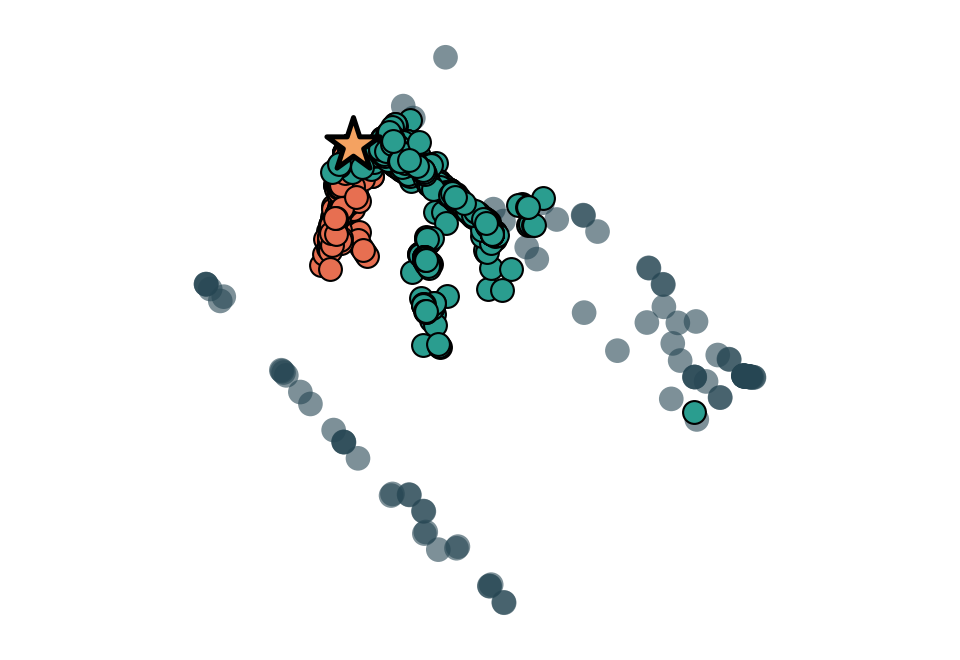

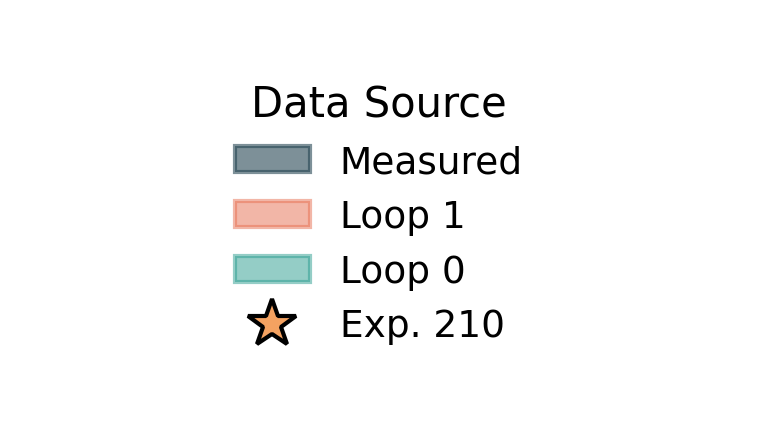

In [30]:
# ---------- colours ----------
cmap = {
    "Measured":   "#264653",   # light gray for real conditions
    "Loop 0": "#2a9d8f",
    "Loop 1": "#e76f51",   # dark red
}
star_color = '#f4a261'     # warm gold for the star
star_edge  = 'black'

# ---------- data masks ----------
mask_real   = joind_PCs_df["Source"] == "Measured"
mask_loop1  = joind_PCs_df["Source"] == "Loop 1"
mask_loop0  = joind_PCs_df["Source"] == "Loop 0"

real_indices = np.where(mask_real)[0]
exp210_real_idx = real_indices[idx_exp210_unique]

# ... (colours and data masks as before)

# ---------- main plot (small, no axes) ----------
plt.figure(figsize=(3, 2), dpi=300, facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# 1. Real
plt.scatter(joind_PCs_df.loc[mask_real, "PC 0"],
            joind_PCs_df.loc[mask_real, "PC 1"],
            c=cmap["Measured"], alpha=0.6, s=35, edgecolor='none', zorder=1)

# 2. Loop 0 – middle layer (light blue dots with black edge)
plt.scatter(joind_PCs_df.loc[mask_loop0, "PC 0"],
            joind_PCs_df.loc[mask_loop0, "PC 1"],
            c=cmap["Loop 0"], #alpha=0.5,
            s=30,
            edgecolor='black', linewidth=0.5,   # small black border
            zorder=3)

# 3. Loop 1 – top layer (red dots with black edge)
plt.scatter(joind_PCs_df.loc[mask_loop1, "PC 0"],
            joind_PCs_df.loc[mask_loop1, "PC 1"],
            c=cmap["Loop 1"], #alpha=0.5,
            s=30,
            edgecolor='black', linewidth=0.5,   # small black border
            zorder=2)
# 4. Star
plt.scatter(joind_PCs_df.loc[exp210_real_idx, "PC 0"],
            joind_PCs_df.loc[exp210_real_idx, "PC 1"],
            marker='*', s=180, facecolor=star_color, edgecolor=star_edge,
            linewidth=1.2, zorder=4)

# ---------- border margin around dots ----------
all_x = np.concatenate([
    joind_PCs_df.loc[mask_real, "PC 0"].values,
    joind_PCs_df.loc[mask_loop0, "PC 0"].values,
    joind_PCs_df.loc[mask_loop1, "PC 0"].values,
])
all_y = np.concatenate([
    joind_PCs_df.loc[mask_real, "PC 1"].values,
    joind_PCs_df.loc[mask_loop0, "PC 1"].values,
    joind_PCs_df.loc[mask_loop1, "PC 1"].values,
])

margin = 0.05  # 5% padding on each side
x_range = all_x.max() - all_x.min()
y_range = all_y.max() - all_y.min()
ax.set_xlim(all_x.min() - margin * x_range, all_x.max() + margin * x_range)
ax.set_ylim(all_y.min() - margin * y_range, all_y.max() + margin * y_range)

# ---------- remove all axes ----------
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])

# keep aspect ratio equal (optional)
ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout(pad=0)
plt.savefig('output/joint_PCA_naked.png', bbox_inches='tight', dpi=300)
plt.show()
# remove axis labels and title (optional – already omitted)
# (no xlabel/ylabel/title calls)


# ---------- separate legend (unchanged) ----------
legend_handles = [
    mpatches.Patch(color=cmap["Measured"], alpha=0.6, label='Measured'),
    mpatches.Patch(color=cmap["Loop 1"], alpha=0.5, label='Loop 1'),
    mpatches.Patch(color=cmap["Loop 0"], alpha=0.5, label='Loop 0'),
    plt.Line2D([0], [0], marker='*', color='w',
               markerfacecolor=star_color, markeredgecolor=star_edge,
               markersize=12, linestyle='None',
               label='Exp. 210')
]

fig_leg = plt.figure(figsize=(3, 1.6), dpi=300)
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
ax_leg.legend(handles=legend_handles, loc='center', frameon=False,
              title='Data Source', title_fontsize=10, fontsize=9)
fig_leg.savefig('output/joint_PCA_legend.png', bbox_inches='tight', dpi=300)
plt.show()


### PCA Of Loop 1 points colored by density.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


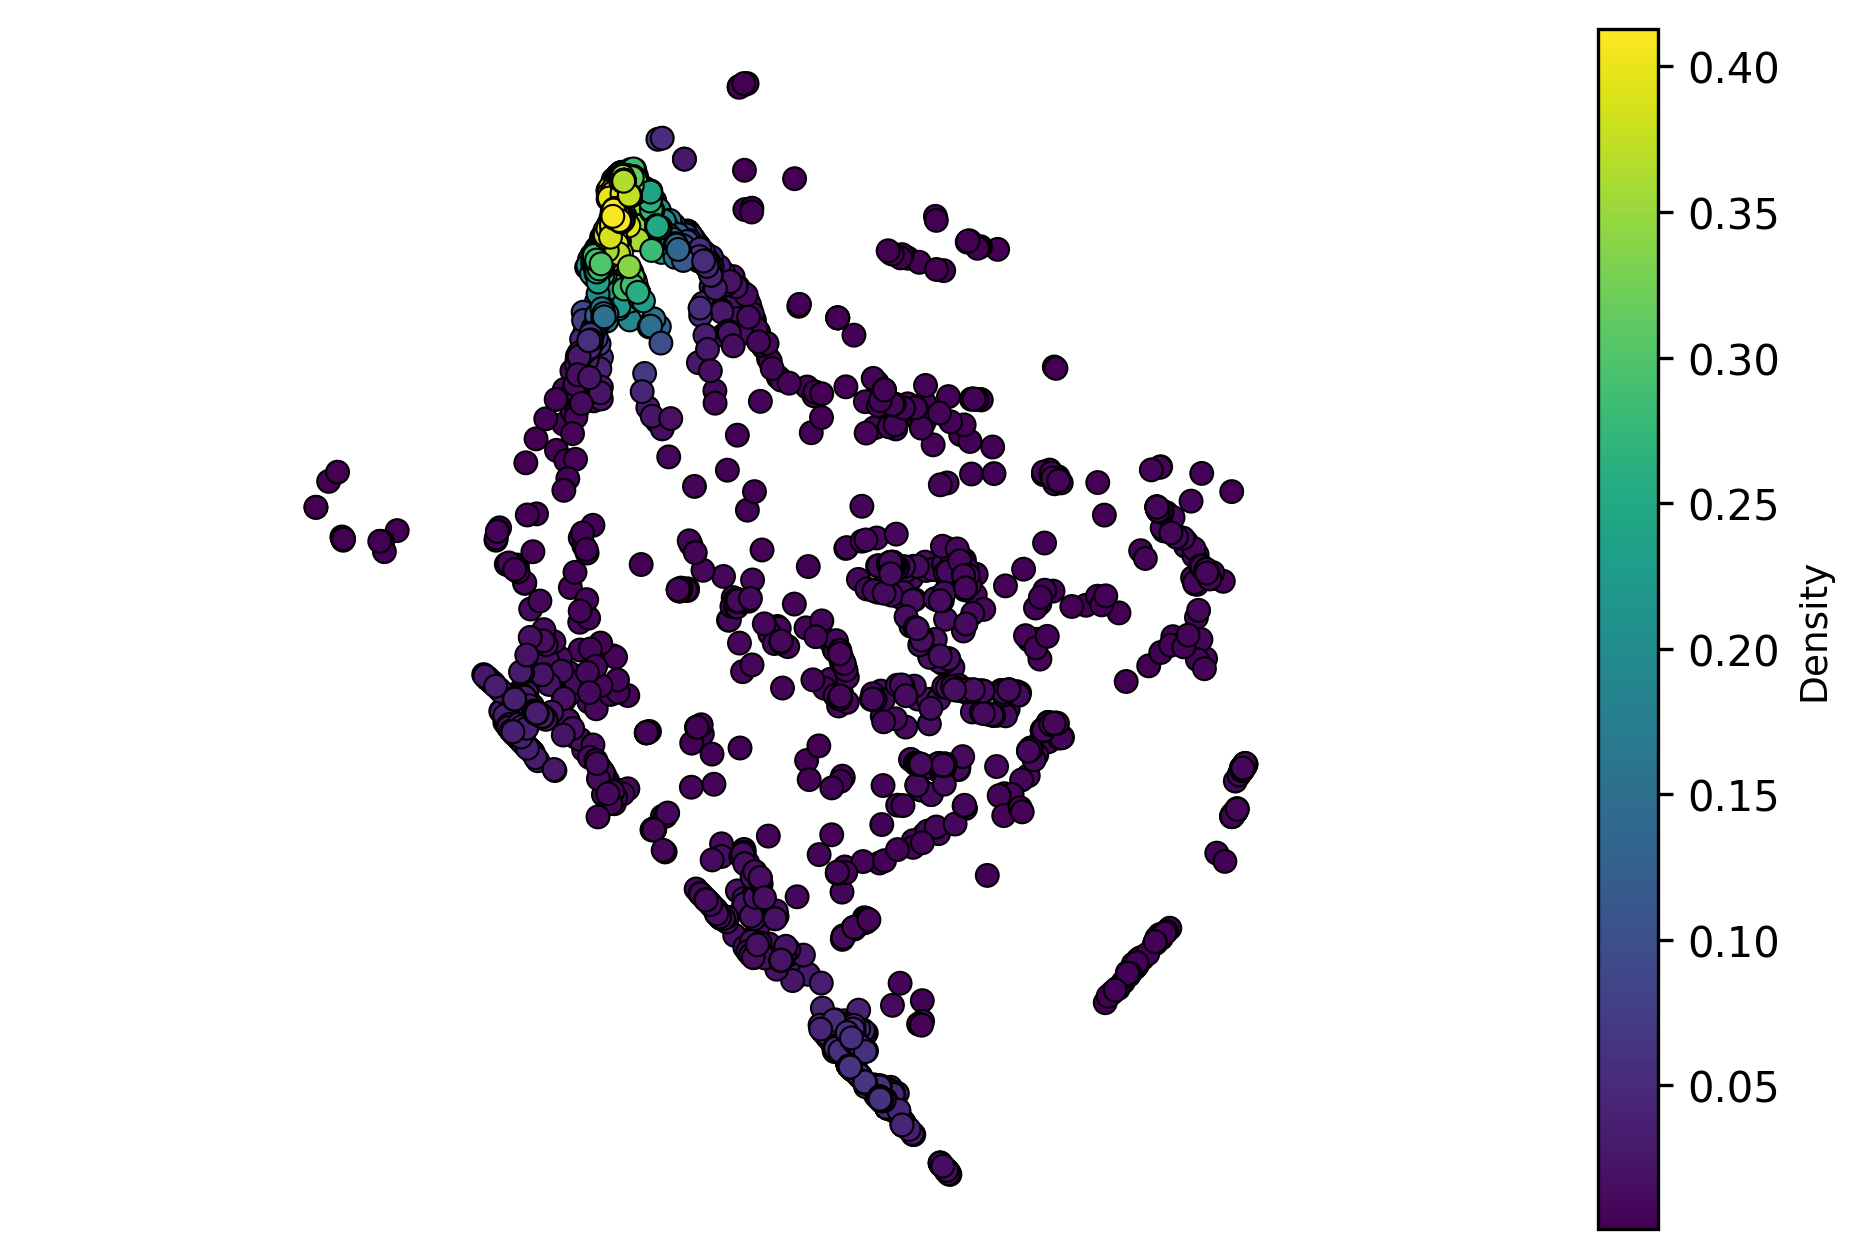

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# ---------- extract Loop 1 points ----------
loop1_df = joind_PCs_df.loc[mask_loop1, ["PC 0", "PC 1"]].copy()
x = loop1_df["PC 0"].values
y = loop1_df["PC 1"].values

# ---------- compute point density ----------
# Stack coordinates and evaluate KDE at each point
kde = gaussian_kde(np.vstack([x, y]))
density = kde(np.vstack([x, y]))   # density at every Loop 1 point

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(6, 4), dpi=300, facecolor='white')
ax.set_facecolor('white')

sc = ax.scatter(
    x, y,
    c=density,
    cmap='viridis',           # or any other colormap (e.g., 'plasma', 'inferno')
    s=30,
    edgecolor='black',
    linewidth=0.5,
    zorder=2
)

# ---------- color bar ----------
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Density', fontsize=9)

# ---------- border margin & equal aspect (same as original) ----------
margin = 0.05
x_range = x.max() - x.min()
y_range = y.max() - y.min()
ax.set_xlim(x.min() - margin * x_range, x.max() + margin * x_range)
ax.set_ylim(y.min() - margin * y_range, y.max() + margin * y_range)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout(pad=0)
plt.savefig('output/loop1_density.png', bbox_inches='tight', dpi=300)
plt.show()

# End-to-End Comparison in terms of Uncertainty and Predicted Cell Type Proportions.

## Prepare Data.

### Create Joint DataFrame.

In [26]:
# ---- Get Mapping of Column Names ----
col_map = {
    "Uncertainty": "target_ct_loss_std",
    "% MgkPro": target_ct_prop,
}

# --- Get Mapped Values ----
mapped_values = {}
for new_col_name, orig_col_name in col_map.items():
    loop0_col = filtered_candidates_loop0[orig_col_name]
    loop1_col = filtered_candidates_loop1[orig_col_name]
    joint_col = np.concatenate(
        (
            loop0_col,
            loop1_col
        ), axis=0
    )
    mapped_values[new_col_name] = joint_col


# ---- Prepare Metadata ----
n_loop0 = len(X_pca_loop0)
n_loop1 = len(X_pca_loop1)
data_source_list = ["Loop 0"]*n_loop0 + ["Loop 1"]*n_loop1
data_source = np.array(data_source_list)

# ---- Prepare uncertainty df ----
joint_uncertainty_df = pd.DataFrame(
    {
        **mapped_values,
        "Source": data_source
    }
)
joint_uncertainty_df


,Uncertainty,% MgkPro,Source
0,0.338706,0.071663,Loop 0
1,0.414317,0.095686,Loop 0
2,0.377195,0.057597,Loop 0
3,0.618461,0.061686,Loop 0
4,0.358764,0.061605,Loop 0
...,...,...,...
6767,0.000000,0.672765,Loop 1
6768,0.000000,0.601473,Loop 1
6769,0.159894,0.105408,Loop 1
6770,0.000000,0.635753,Loop 1


### Plot Comparison Data Uncertainty.

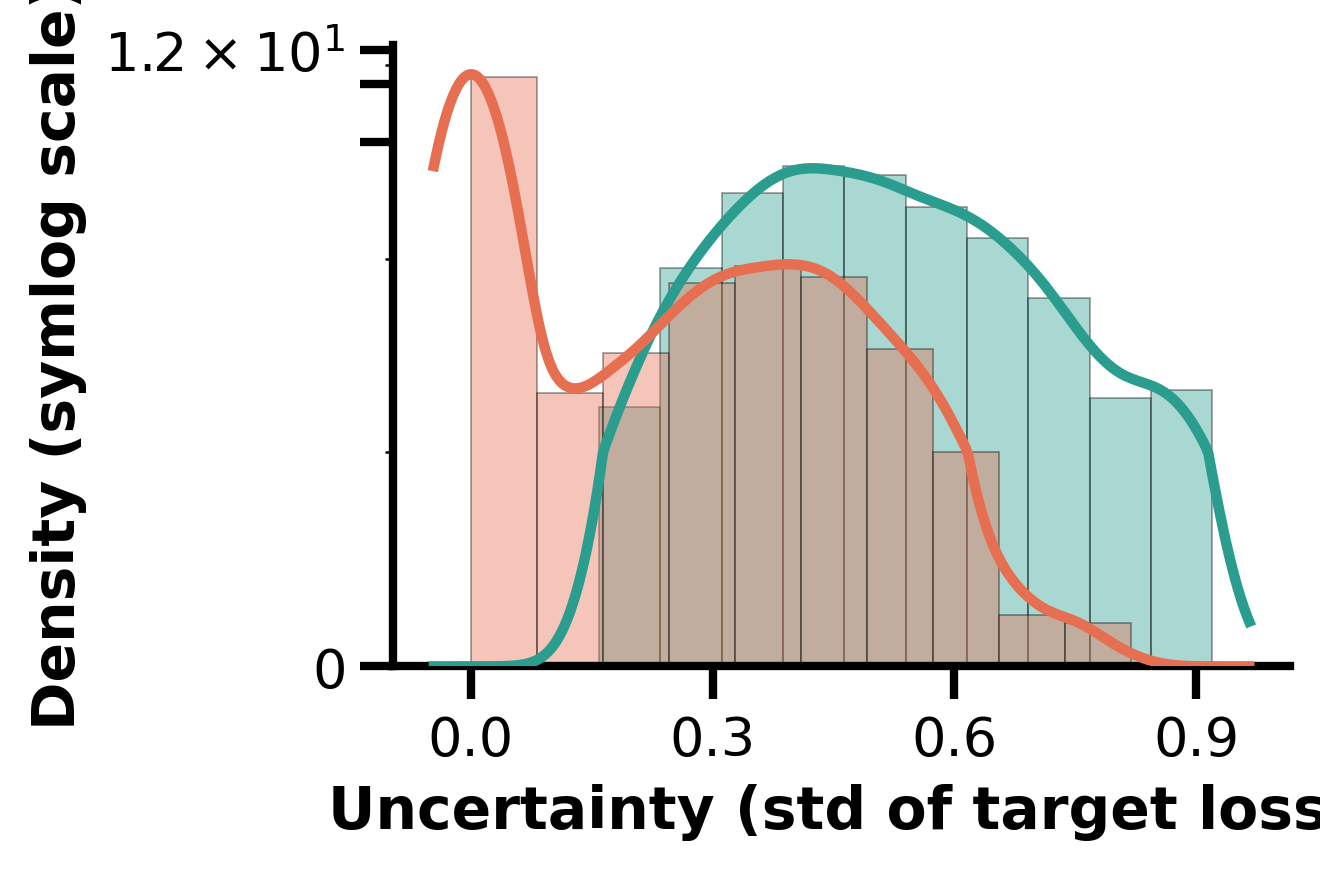

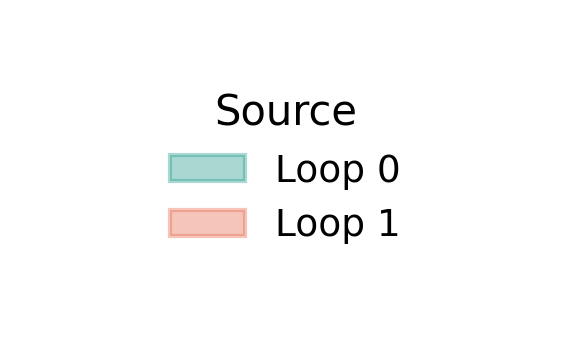

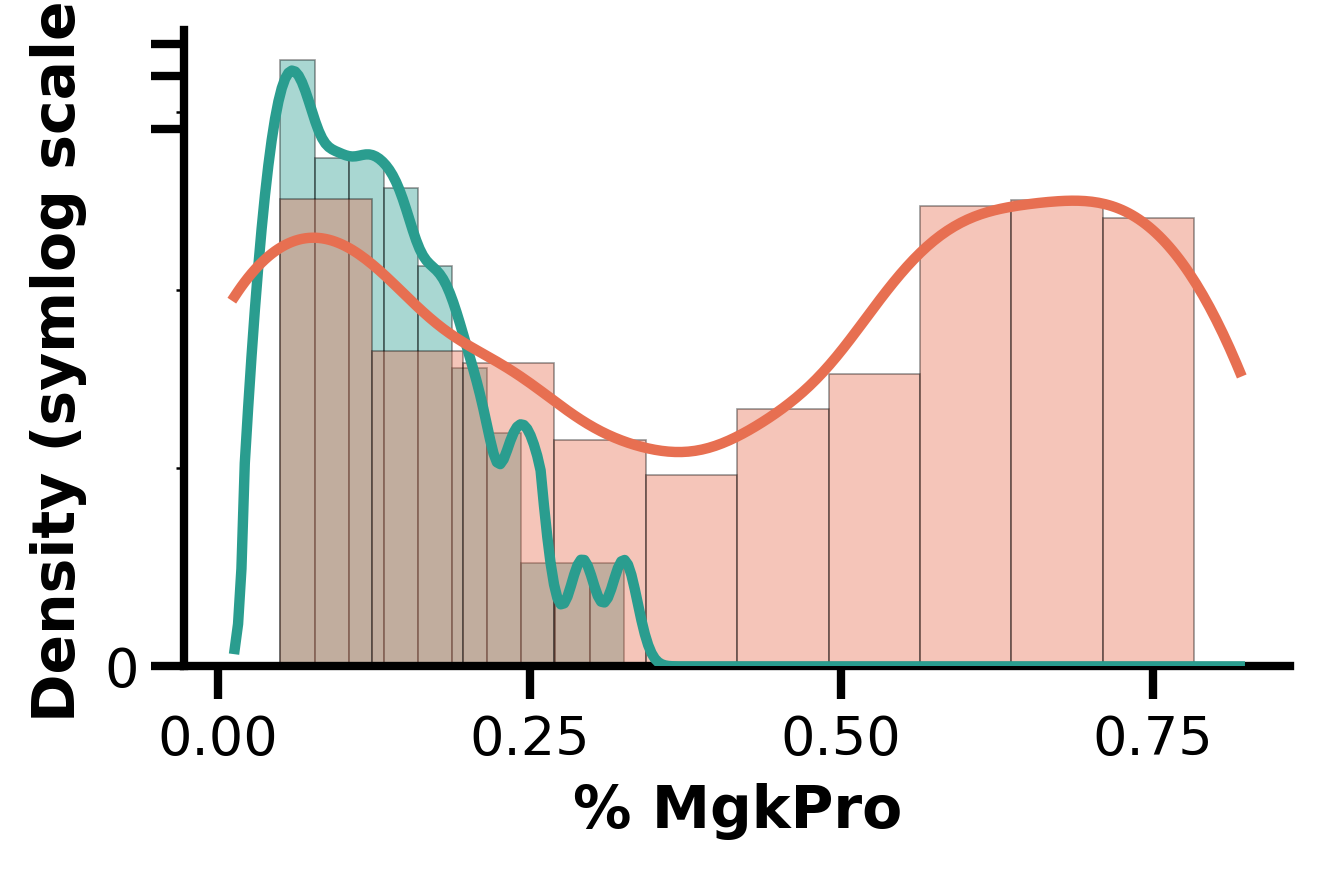

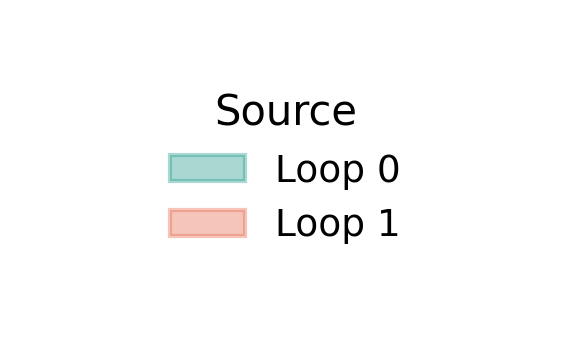

In [38]:
# ---------- function to plot distribution ----------
def plot_distribution(
    df,                      # dataframe
    col_name,                # column to plot (e.g., "Uncertainty", "% MgkPro")
    source_col="Source",     # column with "Loop 0" / "Loop 1"
    loop0_key="Loop 0",
    loop1_key="Loop 1",
    bins=10,
    figsize=(4.5, 3),
    dpi=300,
    save_path=None,
    legend_path=None,
    xlabel=None,
    ylabel="Density (symlog scale)",
    yscale='symlog',        # 'symlog' or 'log'
    linthresh=0.1,          # symlog linear threshold
    palette=None
):
    """Plot overlaid histogram + KDE for two groups, save figure and separate legend."""
    if palette is None:
        palette = cmap
    
    color0 = palette[loop0_key]
    color1 = palette[loop1_key]
    
    # extract data
    mask0 = df[source_col] == loop0_key
    mask1 = df[source_col] == loop1_key
    data0 = df.loc[mask0, col_name].values
    data1 = df.loc[mask1, col_name].values
    
    # ----- plot -----
    plt.figure(figsize=figsize, dpi=dpi, facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')
    
    # histograms
    ax.hist(data0, bins=bins, density=True, alpha=0.4,
            facecolor=color0, edgecolor='black', linewidth=0.4, zorder=2)
    ax.hist(data1, bins=bins, density=True, alpha=0.4,
            facecolor=color1, edgecolor='black', linewidth=0.4, zorder=2)
    
    # KDE curves
    x_min = min(data0.min(), data1.min())
    x_max = max(data0.max(), data1.max())
    pad = 0.05 * (x_max - x_min) if (x_max - x_min) != 0 else 0.1
    x_grid = np.linspace(x_min - pad, x_max + pad, 300)
    kde0 = gaussian_kde(data0)
    kde1 = gaussian_kde(data1)
    ax.plot(x_grid, kde0(x_grid), color=color0, linewidth=2.5, zorder=3)
    ax.plot(x_grid, kde1(x_grid), color=color1, linewidth=2.5, zorder=3)
    
    # symlog (or log) scale
    if yscale == 'symlog':
        ax.set_yscale('symlog', linthresh=linthresh)
    else:
        ax.set_yscale(yscale)
    
    # styling
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    ax.tick_params(axis='both', which='major',
                   labelsize=13, length=8, width=2, color='black')
    ax.set_xlabel(xlabel if xlabel else col_name, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    
    sns.despine()
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=dpi)
    plt.show()
    
    # ----- separate legend -----
    legend_handles = [
        mpatches.Patch(color=color0, alpha=0.4, label=loop0_key),
        mpatches.Patch(color=color1, alpha=0.4, label=loop1_key)
    ]
    fig_leg = plt.figure(figsize=(2.2, 1.2), dpi=dpi)
    ax_leg = fig_leg.add_subplot(111)
    ax_leg.axis('off')
    ax_leg.legend(handles=legend_handles, loc='center', frameon=False,
                  title='Source', title_fontsize=10, fontsize=9)
    if legend_path:
        fig_leg.savefig(legend_path, bbox_inches='tight', dpi=dpi)
    plt.show()

# ============================================================
# usage
# ============================================================
plot_distribution(
    df=joint_uncertainty_df,
    col_name="Uncertainty",
    xlabel="Uncertainty (std of target loss)",
    save_path="output/uncertainty_distribution.png",
    legend_path="output/uncertainty_legend.png",
    yscale='symlog', linthresh=0.1
)

plot_distribution(
    df=joint_uncertainty_df,
    col_name="% MgkPro",
    xlabel="% MgkPro",
    save_path="output/mgkpro_distribution.png",
    legend_path="output/mgkpro_legend.png",
    yscale='symlog', linthresh=0.1
)


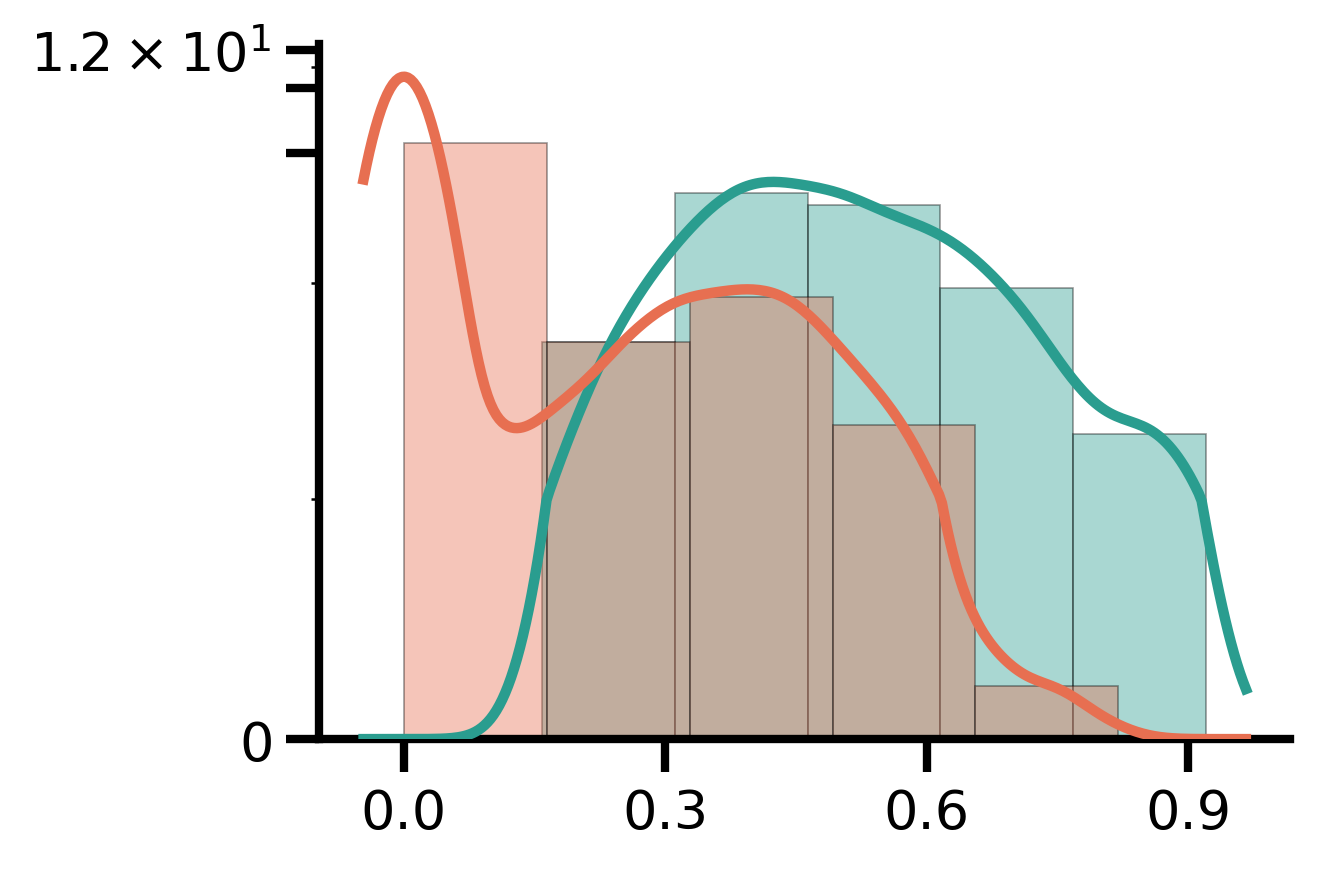

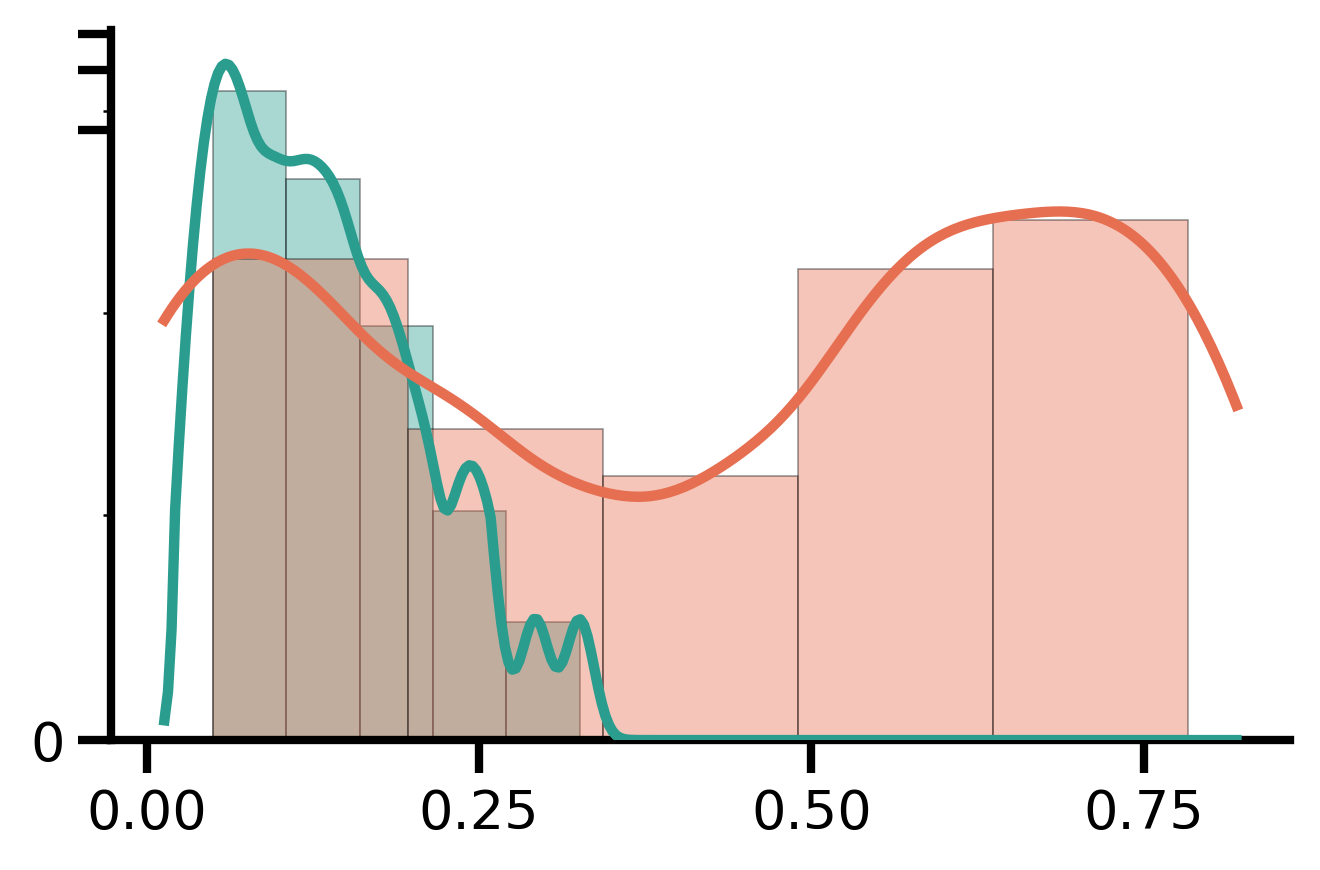

In [41]:
def plot_distribution(
    df,
    col_name,
    source_col="Source",
    loop0_key="Loop 0",
    loop1_key="Loop 1",
    bins=5,
    figsize=(4.5, 4.5),
    dpi=300,
    save_path=None,
    legend_path=None,
    xlabel=None,
    ylabel="Density (symlog scale)",
    yscale='symlog',
    linthresh=0.1,
    palette=None,
    naked=False,
    remove_ax_titles=True,
):
    if palette is None:
        palette = cmap

    color0 = palette[loop0_key]
    color1 = palette[loop1_key]

    mask0 = df[source_col] == loop0_key
    mask1 = df[source_col] == loop1_key
    data0 = df.loc[mask0, col_name].values
    data1 = df.loc[mask1, col_name].values

    # ----- figure -----
    plt.figure(figsize=figsize, dpi=dpi, facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    # histograms
    ax.hist(data0, bins=bins, density=True, alpha=0.4,
            facecolor=color0, edgecolor='black', linewidth=0.4, zorder=2)
    ax.hist(data1, bins=bins, density=True, alpha=0.4,
            facecolor=color1, edgecolor='black', linewidth=0.4, zorder=2)

    # KDE
    x_min = min(data0.min(), data1.min())
    x_max = max(data0.max(), data1.max())
    pad = 0.05 * (x_max - x_min) if (x_max - x_min) != 0 else 0.1
    x_grid = np.linspace(x_min - pad, x_max + pad, 300)
    kde0 = gaussian_kde(data0)
    kde1 = gaussian_kde(data1)
    ax.plot(x_grid, kde0(x_grid), color=color0, linewidth=2.5, zorder=3)
    ax.plot(x_grid, kde1(x_grid), color=color1, linewidth=2.5, zorder=3)

    # scale
    if yscale == 'symlog':
        ax.set_yscale('symlog', linthresh=linthresh)
    else:
        ax.set_yscale(yscale)

    # ----- naked style: thick spines, ticks visible but no labels -----
    if naked:
        # make all four spines visible and thick
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2.5)        # extra thick

        # set tick marks with length/width but hide labels
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.tick_params(axis='both', which='major',
                       length=8, width=2, color='black',
                       labelleft=False, labelbottom=False)   # no text

        # remove axis titles (if any)
        if remove_ax_titles:
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.set_title('')

    else:
        # standard styling: left & bottom spines only, labels, ticks
        for spine in ax.spines.values():
            spine.set_linewidth(2)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.tick_params(axis='both', which='major',
                       labelsize=13, length=8, width=2, color='black')
        ax.set_xlabel(xlabel if xlabel else col_name, fontsize=14, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
        sns.despine()


        # remove axis titles (if any)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title('')


    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=dpi)
    plt.show()

    # legend only for non‑naked plots
    if not naked and legend_path:
        legend_handles = [
            mpatches.Patch(color=color0, alpha=0.4, label=loop0_key),
            mpatches.Patch(color=color1, alpha=0.4, label=loop1_key)
        ]
        fig_leg = plt.figure(figsize=(2.2, 1.2), dpi=dpi)
        ax_leg = fig_leg.add_subplot(111)
        ax_leg.axis('off')
        ax_leg.legend(handles=legend_handles, loc='center', frameon=False,
                      title='Source', title_fontsize=10, fontsize=9)
        fig_leg.savefig(legend_path, bbox_inches='tight', dpi=dpi)
        plt.show()

# Naked Uncertainty
plot_distribution(
    df=joint_uncertainty_df,
    col_name="Uncertainty",
    save_path="output/uncertainty_distribution_naked.png",
    yscale='symlog', linthresh=0.1,
    # naked=True,
    figsize=(4.5, 3)
)

# Naked % MgkPro
plot_distribution(
    df=joint_uncertainty_df,
    col_name="% MgkPro",
    save_path="output/mgkpro_distribution_naked.png",
    yscale='symlog', linthresh=0.1,
    # naked=True,
    figsize=(4.5, 3)
)
